In [ ]:
# Pandas Profilingのインストール
!pip install git+https://github.com/pandas-profiling/pandas-profiling.git
!pip show pandas_profiling

In [ ]:
# AutoKerasのインストール
!pip install autokeras

In [2]:
from sklearn.datasets import load_wine

wine = load_wine()    # データセットの読み込み
print(wine)           # データセットの表示

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
 

In [ ]:
import pandas as pd

# 説明変数を格納
wine_data = pd.DataFrame(wine.data,                   # ワインの成分データ
                         columns=wine.feature_names)  # ワインの成分名
# 目的変数を格納
wine_target = pd.DataFrame(wine.target,               # ワインの品種データ
                           columns=['target'])        # ワインの品種名
df = pd.concat([wine_data, wine_target], axis=1)      # 説明変数と目的変数を結合

print(df.shape)     # データセットのサイズ
df.head()           # データセットの表示

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
from pandas_profiling import ProfileReport

df_prof = ProfileReport(df) # プロファイル・レポートの作成
df_prof                     # プロファイル・レポートの表示

Summarize dataset:   0%|          | 0/27 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
from sklearn.model_selection import train_test_split

# 学習データと評価データを作成
trainX, testX, trainY, testY = train_test_split(wine.data,      # 説明変数
                                                wine.target,    # 目的変数
                                                test_size=0.1)  # 全体の1割が評価データ

print(trainX.shape, trainY.shape) # 学習データのサイズ
print(testX.shape, testY.shape)   # 評価データのサイズ

(160, 13) (160,)
(18, 13) (18,)


In [9]:
pd.DataFrame(trainX, columns=wine.feature_names).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,13.05,1.73,2.04,12.4,92.0,2.72,3.27,0.17,2.91,7.20,1.12,2.91,1150.0
1,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
2,13.11,1.90,2.75,25.5,116.0,2.20,1.28,0.26,1.56,7.10,0.61,1.33,425.0
3,11.66,1.88,1.92,16.0,97.0,1.61,1.57,0.34,1.15,3.80,1.23,2.14,428.0
4,14.19,1.59,2.48,16.5,108.0,3.30,3.93,0.32,1.86,8.70,1.23,2.82,1680.0


In [10]:
from sklearn.preprocessing import MinMaxScaler

# 学習データを範囲変換
mc = MinMaxScaler().fit(trainX)
trainX = mc.transform(trainX)

print(trainX.shape)  # 変換後のデータサイズ
print(trainX)        # 変換後のデータ

(160, 13)
[[0.53157895 0.19565217 0.36363636 ... 0.5203252  0.6007326  0.62196862]
 [0.83421053 0.20158103 0.5828877  ... 0.46341463 0.57875458 0.83594864]
 [0.54736842 0.22924901 0.74331551 ... 0.10569106 0.02197802 0.10485021]
 ...
 [0.56052632 0.55928854 0.42245989 ... 0.09756098 0.15018315 0.39372325]
 [0.27631579 0.21541502 0.51336898 ... 0.48780488 0.36630037 0.14407989]
 [0.11052632 0.32806324 0.56684492 ... 0.2601626  0.77655678 0.24750357]]


In [11]:
pd.DataFrame(trainX, columns=wine.feature_names).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.531579,0.195652,0.363636,0.092784,0.239130,0.606272,0.618143,0.08,0.788644,0.505119,0.520325,0.600733,0.621969
1,0.834211,0.201581,0.582888,0.237113,0.456522,0.797909,0.643460,0.42,0.492114,0.466724,0.463415,0.578755,0.835949
2,0.547368,0.229249,0.743316,0.768041,0.500000,0.425087,0.198312,0.26,0.362776,0.496587,0.105691,0.021978,0.104850
3,0.165789,0.225296,0.299465,0.278351,0.293478,0.219512,0.259494,0.42,0.233438,0.215017,0.609756,0.318681,0.106990
4,0.831579,0.167984,0.598930,0.304124,0.413043,0.808362,0.757384,0.38,0.457413,0.633106,0.609756,0.567766,1.000000


In [12]:
pd.DataFrame(testX, columns=wine.feature_names).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,11.84,2.89,2.23,18.0,112.0,1.72,1.32,0.43,0.95,2.65,0.96,2.52,500.0
1,14.22,1.70,2.30,16.3,118.0,3.20,3.00,0.26,2.03,6.38,0.94,3.31,970.0
2,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
3,13.41,3.84,2.12,18.8,90.0,2.45,2.68,0.27,1.48,4.28,0.91,3.00,1035.0
4,13.82,1.75,2.42,14.0,111.0,3.88,3.74,0.32,1.87,7.05,1.01,3.26,1190.0


In [13]:
# 評価データを範囲変換
testX = mc.transform(testX)

print(testX.shape)  # 変換後のデータサイズ
print(testX)        # 変換後のデータ

(18, 13)
[[0.21315789 0.42490119 0.46524064 0.3814433  0.45652174 0.25783972
  0.20675105 0.6        0.170347   0.1168942  0.3902439  0.45787546
  0.15834522]
 [0.83947368 0.18972332 0.5026738  0.29381443 0.52173913 0.77351916
  0.56118143 0.26       0.51104101 0.43515358 0.37398374 0.74725275
  0.4935806 ]
 [0.79736842 0.27865613 0.6684492  0.36082474 0.55434783 0.56445993
  0.45780591 0.36       0.26498423 0.32167235 0.47154472 0.84615385
  0.7253923 ]
 [0.62631579 0.61264822 0.40641711 0.42268041 0.2173913  0.51219512
  0.49367089 0.28       0.33753943 0.2559727  0.3495935  0.63369963
  0.53994294]
 [0.73421053 0.19960474 0.56684492 0.17525773 0.44565217 1.01045296
  0.71729958 0.38       0.46056782 0.49232082 0.43089431 0.72893773
  0.65049929]
 [0.36578947 0.35770751 0.48663102 0.58762887 0.2173913  0.24390244
  0.3164557  1.06       0.31861199 0.12116041 0.30894309 0.74358974
  0.02639087]
 [0.58157895 0.64031621 0.4973262  0.3556701  0.35869565 0.57839721
  0.48312236 0.38      

In [14]:
pd.DataFrame(testX, columns=wine.feature_names).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.213158,0.424901,0.465241,0.381443,0.456522,0.257840,0.206751,0.60,0.170347,0.116894,0.390244,0.457875,0.158345
1,0.839474,0.189723,0.502674,0.293814,0.521739,0.773519,0.561181,0.26,0.511041,0.435154,0.373984,0.747253,0.493581
2,0.797368,0.278656,0.668449,0.360825,0.554348,0.564460,0.457806,0.36,0.264984,0.321672,0.471545,0.846154,0.725392
3,0.626316,0.612648,0.406417,0.422680,0.217391,0.512195,0.493671,0.28,0.337539,0.255973,0.349593,0.633700,0.539943
4,0.734211,0.199605,0.566845,0.175258,0.445652,1.010453,0.717300,0.38,0.460568,0.492321,0.430894,0.728938,0.650499


In [66]:
import tensorflow as tf
import autokeras as ak

# 学習条件の設定
clf = ak.StructuredDataClassifier(overwrite=True, # プロジェクト上書き
                                  max_trials=3)   # 試行回数
# モデルの学習
clf.fit(trainX,                 # 説明変数 
        trainY,                 # 目的変数
        validation_split=0.1,   # 全体の1割がテストデータ
        epochs=10)              # エポック数

Trial 3 Complete [00h 00m 03s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 09s
INFO:tensorflow:Oracle triggered exit
Epoch 1/10
5/5 [==============================] - 1s 4ms/step - loss: 0.6279 - accuracy: 0.7387
Epoch 2/10
5/5 [==============================] - 0s 3ms/step - loss: 0.0595 - accuracy: 0.9760
Epoch 3/10
5/5 [==============================] - 0s 3ms/step - loss: 0.0098 - accuracy: 0.9871
Epoch 4/10
5/5 [==============================] - 0s 3ms/step - loss: 1.2224e-04 - accuracy: 1.0000
Epoch 5/10
5/5 [==============================] - 0s 4ms/step - loss: 7.7787e-05 - accuracy: 1.0000
Epoch 6/10
5/5 [==============================] - 0s 3ms/step - loss: 6.9672e-06 - accuracy: 1.0000
Epoch 7/10
5/5 [==============================] - 0s 4ms/step - loss: 3.5294e-05 - accuracy: 1.0000
Epoch 8/10
5/5 [==============================] - 0s 3ms/step - loss: 1.8514e-05 - accuracy: 1.0000
Epoch 9/10
5/5 [==============================] - 0s 4ms/step 

In [67]:
from sklearn.metrics import classification_report

pred = clf.predict(testX).flatten().astype('int32')   # 評価データにモデルを適用
print(classification_report(testY, pred))             # モデル精度、再現率、適合率の計算

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



In [68]:
model = clf.export_model()    # 学習したモデルの出力
model.summary()               # 学習したモデルの概要

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 13)]              0         
_________________________________________________________________
multi_category_encoding (Mul (None, 13)                0         
_________________________________________________________________
normalization (Normalization (None, 13)                27        
_________________________________________________________________
dense (Dense)                (None, 32)                448       
_________________________________________________________________
re_lu (ReLU)                 (None, 32)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 32)                1056      
_________________________________________________________________
re_lu_1 (ReLU)               (None, 32)                0     

In [69]:
from tensorflow.keras import layers

hid_out = tf.keras.models.Sequential()
# 学習したモデルの再利用
hid_out.add(model.layers[0])
hid_out.add(model.layers[1])
hid_out.add(model.layers[2])
hid_out.add(model.layers[3])
hid_out.add(model.layers[4])
# 新たに1層追加
hid_out.add(layers.Dense(2, activation='relu'))

hid_out.summary()   # 作成したモデルの概要

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
multi_category_encoding (Mul (None, 13)                0         
_________________________________________________________________
normalization (Normalization (None, 13)                27        
_________________________________________________________________
dense (Dense)                (None, 32)                448       
_________________________________________________________________
re_lu (ReLU)                 (None, 32)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 2)                 66        
Total params: 541
Trainable params: 514
Non-trainable params: 27
_________________________________________________________________


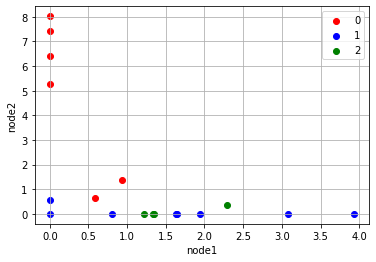

In [73]:
import matplotlib.pyplot as plt

output = hid_out.predict(testX)     # 評価データにモデルを適用

## モデル出力結果の整形
output = pd.DataFrame(output)
testY = pd.DataFrame(testY).rename(columns={0:'target'})
hid_test = pd.concat([output, testY], axis=1)

## モデル出力を可視化
# 0の描画
hid_test0 = hid_test[hid_test['target'] == 0]
hid_test0 = hid_test0.drop('target', axis=1)
plt.scatter(hid_test0[0], hid_test0[1], c='red', label=0)
# 1の描画
hid_test1 = hid_test[hid_test['target'] == 1]
hid_test1 = hid_test1.drop('target', axis=1)
plt.scatter(hid_test1[0], hid_test1[1], c='blue', label=1)
# 2の描画
hid_test2 = hid_test[hid_test['target'] == 2]
hid_test2 = hid_test2.drop('target', axis=1)
plt.scatter(hid_test2[0], hid_test2[1], c='green', label=2)

plt.xlabel('node1')   # x軸のラベル名
plt.ylabel('node2')   # y軸のラベル名
plt.legend()          # 凡例を設定
plt.grid()
plt.show()